In [34]:
import pandas as pd

from nlp_content_validity.data.read_data import read_dataset
import numpy as np
from nlp_content_validity.features.compute_similarities import iterate_on_scale

In [28]:
definitions, df, focal_scales, orbiting_dict = read_dataset('colquitt_et_al')

In [29]:
df['Abbreviation'] = [f'scale{i}' for i in range(1, len(df) + 1)]

In [30]:
df.head()

,scale,item,Abbreviation
code,,,
ALB01,Avoidant Leader Behaviors,My branch manager will not discuss issues that...,scale1
ALB02,Avoidant Leader Behaviors,My branch manager cuts off discussion as soon ...,scale2
ALB03,Avoidant Leader Behaviors,My branch manager does not get involved in emp...,scale3
ALB04,Avoidant Leader Behaviors,My branch manager avoids getting involved in m...,scale4
SIS01,Supervisor Initiating Structure,Lets group members know what is expected of them,scale5


In [12]:
df['Definition'] = df.scale.map(definitions)

In [13]:
df.rename(columns={'scale': 'Construct name'}, inplace=True)

In [15]:
df.head()

,Construct name,item,Abbreviation,Definition
code,,,,
Abusive supervision - active-aggressive,Abusive supervision - active-aggressive,"My supervisor was abusive, saying or doing thi...",scale1,Abusive supervision (active-aggressive) is def...
Affective commitment,Affective commitment,I felt emotionally attached to my organization.,scale2,Affective commitment is defined as an employee...
Authoritarian leadership,Authoritarian leadership,My supervisor asserted absolute control and au...,scale3,Authoritarian leadership is defined as the deg...
Autonomy climate,Autonomy climate,My organization designs jobs in ways which giv...,scale4,Autonomy climate is defined as the shared perc...
Bureaucracy,Bureaucracy,My organization has a lot of bureaucracy; ever...,scale5,Bureaucracy is defined as the extent to which ...


In [16]:
df['Reversed item'] = ''

sheet  1: Definitions

Construct name	Abbreviation	Definition

sheet 2: Items

Expected target construct	Reversed item	Item statement

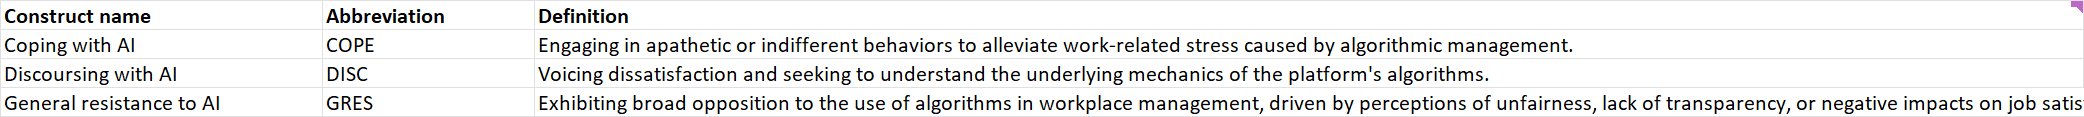

In [27]:
for i, df_ in enumerate(np.array_split(df, 10)):

    out_fname = f'../../data/processed/matthews_et_al_contval_{i}.xlsx'
    writer = pd.ExcelWriter(out_fname, )

    df_[['Construct name', 'Abbreviation', 'Definition']].to_excel(
        writer, sheet_name = 'Definitions', index = False)

    df_.rename(columns={'item': 'Item statement',
                       'Abbreviation': 'Expected target'
                       })[['Expected target', 'Reversed item', 'Item statement']].to_excel(
        writer, sheet_name = 'Items', index = False)

    # writer.save()
    writer.close()


C:\Users\matti\PycharmProjects\nlp_content_validity\.venv1\lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [ ]:
test =  pd.read_excel('data/processed/train_val_test.xlsx', sheet_name = 'test')[['definition', 'ItemText', 'Target']].clean_names()
data_test_dict = []

for i, _ in test.iterrows():
    data_test_dict.append({'text': test['definition'][i],
                           'text_pair': test['itemtext'][i]})


In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import torch
import numpy as np
import pandas as pd
import janitor

from datasets import DatasetDict, Dataset

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, TextClassificationPipeline

from scipy.special import softmax
from sklearn.metrics import roc_auc_score
import random
from transformers import set_seed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device
seed = 123

set_seed(seed)
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)




In [ ]:
def contval_raterc_similarity(definitions, df, focal_scales, orbiting_dict, model, batch_size):
    results = list()
    for scale_focal, items, scale, definition in iterate_on_scale(definitions, df, focal_scales, orbiting_dict):

        data_test_dict = []

        for i, _ in test.iterrows():
            data_test_dict.append({'text': definition,
                                   'text_pair': item})

        raw_probs = model(data_test_dict, batch_size = batch_size)
        probs = np.array([item[['LABEL_1' == i['label'] for i in item].index(True)]['score'] for item in raw_probs])

        results.append({scale_focal: {scale:
                                          probs.tolist()}})
    return results


In [35]:

for dataset in ['colquitt_et_al', 'matthews_et_al']:
    to_format = list()
    definitions, df, focal_scales, orbiting_dict = read_dataset(dataset)

    for scale_focal, items, scale, definition in iterate_on_scale(definitions, df, focal_scales, orbiting_dict):
        for item in items:
            to_format.append(dict(definition=definition, itemtext=item))

    pd.DataFrame(to_format).to_csv(f'../../data/interim/raterd_input_{dataset}.csv', index=False)

100%|██████████| 91/91 [00:00<00:00, 6253.59it/s]


In [37]:
import json
for dataset in ['colquitt_et_al', 'matthews_et_al']:
    results = list()

    definitions, df, focal_scales, orbiting_dict = read_dataset(dataset)

    with open(f'../../data/interim/{dataset}.jsonl') as f:

        for scale_focal, items, scale, definition in iterate_on_scale(definitions, df, focal_scales, orbiting_dict):
            item_results=list()
            for item in items:
                output = json.loads(next(f))
                item_results.append(output['pred'])
            results.append({scale_focal: {scale:
                              item_results}})

    with open(f'../../data/interim/{dataset}/llm_contval_raterd.json', 'w') as f:
        json.dump(results, f)

100%|██████████| 91/91 [00:00<00:00, 11389.06it/s]
